<a href="https://colab.research.google.com/github/Pradipta2/uts-bi/blob/main/UTS_BI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('caffeine.csv')

# Lihat data
df.head()

,drink,Volume (ml),Calories,Caffeine (mg),type
0,Costa Coffee,256.993715,0,277,Coffee
1,Coffee Friend Brewed Coffee,250.191810,0,145,Coffee
2,Hell Energy Coffee,250.191810,150,100,Coffee
3,Killer Coffee (AU),250.191810,0,430,Coffee
4,Nescafe Gold,250.191810,0,66,Coffee


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   drink          610 non-null    object 
 1   Volume (ml)    610 non-null    float64
 2   Calories       610 non-null    int64  
 3   Caffeine (mg)  610 non-null    int64  
 4   type           610 non-null    object 
dtypes: float64(1), int64(2), object(2)
memory usage: 24.0+ KB


,0
drink,0
Volume (ml),0
Calories,0
Caffeine (mg),0
type,0


In [4]:
df.columns = ['drink', 'volume', 'calories', 'caffeine', 'type']

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [6]:
X = df[['volume', 'calories', 'caffeine']]
y = df['type']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

### Hyperparameter Tuning for Random Forest

Saya akan menggunakan `GridSearchCV` untuk mencari hyperparameter terbaik untuk `RandomForestClassifier`. Ini akan membantu meningkatkan akurasi model dengan menguji berbagai kombinasi parameter.

In [13]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_depth': [None, 10, 20, 30], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],   # Minimum number of samples required to be at a leaf node
    'criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), # Add random_state for reproducibility
                           param_grid=param_grid,
                           cv=5, # 5-fold cross-validation
                           n_jobs=-1, # Use all available cores
                           verbose=1, # Display progress
                           scoring='accuracy') # Metric to optimize

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score found
print("Best parameters found by GridSearchCV:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

# Get the best estimator (model) from GridSearchCV
best_rf = grid_search.best_estimator_

# Predict on the test set using the best model
y_pred_best_rf = best_rf.predict(X_test)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits


KeyboardInterrupt: 

### Evaluation of Tuned Random Forest Model

Sekarang mari kita evaluasi performa model Random Forest yang telah disetel hyperparameter-nya pada data uji.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))

print("\n=== Tuned Random Forest Report ===")
print(classification_report(y_test, y_pred_best_rf))

# Display confusion matrix for the tuned model
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_tuned_rf = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\n=== Decision Tree Report ===")
print(classification_report(y_test, y_pred_dt))

print("\n=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

Decision Tree Accuracy: 0.6147540983606558
Random Forest Accuracy: 0.680327868852459

=== Decision Tree Report ===
              precision    recall  f1-score   support

           0       0.70      0.61      0.65        38
           1       0.68      0.62      0.65        45
           2       0.83      1.00      0.91         5
           3       0.53      0.75      0.62        12
           4       0.53      0.56      0.55        16
           5       0.12      0.17      0.14         6

    accuracy                           0.61       122
   macro avg       0.57      0.62      0.59       122
weighted avg       0.63      0.61      0.62       122


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.71      0.66      0.68        38
           1       0.71      0.71      0.71        45
           2       0.83      1.00      0.91         5
           3       0.55      0.92      0.69        12
           4       0.82      0.56      0.

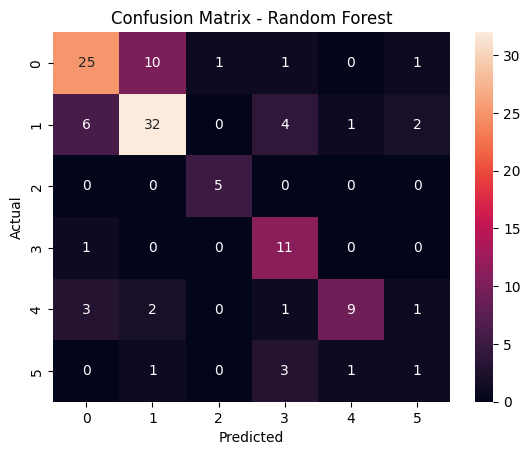

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

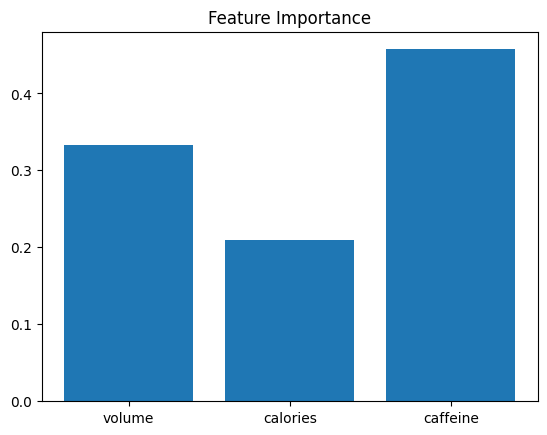

In [12]:
importances = rf.feature_importances_
features = X.columns

plt.bar(features, importances)
plt.title("Feature Importance")
plt.show()